In [1]:
import numpy as np
from gpcam import GPOptimizer

import pandas as pd

from sklearn.datasets import load_digits

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

from sklearn.neighbors import NearestNeighbors

import warnings
# Add this at the top of your code or before running experiments
warnings.filterwarnings("ignore", message="No noise function or measurement noise provided.*")

from scipy.spatial.distance import cdist


# Load the Data

In [2]:
print("="*70)
print("Step 1: Loading and normalizing full dataset")
print("="*70)

digits = load_digits()
X_full = digits.data.copy()
numerical_values = digits.target

# Convert to binary classification
y_full = (numerical_values >= 5).astype(float)

# Normalize ALL data to probability distributions
print(f"\nNormalizing {len(X_full)} samples...")
for i in range(len(X_full)):
    X_full[i] = (X_full[i] - np.min(X_full[i])) + 1e-8
    X_full[i] = X_full[i] / np.sum(X_full[i])

print(f"✅ Full dataset: {X_full.shape}")
print(f"✅ Binary labels: {y_full.shape}")

Step 1: Loading and normalizing full dataset

Normalizing 1797 samples...
✅ Full dataset: (1797, 64)
✅ Binary labels: (1797,)


# GP Model Components

In [21]:
from sklearn.model_selection import train_test_split

# ===== LOAD PRECOMPUTED MATRICES =====
print("="*70)
print("Loading precomputed data and distances")
print("="*70)

# Choose which distance metric to use
DISTANCE_METRIC = 'Wass2D'  # Options: 'JS', 'Wass2D', 'GW', 'FGW', 'sliced_Wass'

distance_full = np.load(f'digits_distance_{DISTANCE_METRIC}.npy')
print(f"✅ Loaded {DISTANCE_METRIC} distance matrix: {distance_full.shape}")

# ===== SPLIT INTO TRAIN/TEST =====
print("\n" + "="*70)
print("Splitting into train/test and extracting submatrices")
print("="*70)


# Split indices (not data directly)
indices = np.arange(len(X_full))
train_idx_unsorted, test_idx_unsorted = train_test_split(indices, test_size=0.3, random_state=42, stratify=y_full)

# Sort indices to preserve original order
train_idx = np.sort(train_idx_unsorted)
test_idx = np.sort(test_idx_unsorted)

print(f"✅ Train indices (sorted): {train_idx[:10]}...")  # Show first 10
print(f"✅ Test indices (sorted): {test_idx[:10]}...")

# # Extract train and test data (now in original order)
# X_train = X_full[train_idx]
# X_test = X_full[test_idx]
y_train = y_full[train_idx]
y_test = y_full[test_idx]

# Use the sorted indices as "features"
X_train = train_idx.reshape(-1, 1)  # Shape: (n_train, 1)
X_test = test_idx.reshape(-1, 1)    # Shape: (n_test, 1)

print(f"X_train_gp shape: {X_train.shape}")
print(f"X_test_gp shape: {X_test.shape}")
print(f"y_train_binary shape: {y_train.shape}")


Loading precomputed data and distances
✅ Loaded Wass2D distance matrix: (1797, 1797)

Splitting into train/test and extracting submatrices
✅ Train indices (sorted): [ 0  2  3  6  7 10 11 12 13 14]...
✅ Test indices (sorted): [ 1  4  5  8  9 15 19 23 24 25]...
X_train_gp shape: (1257, 1)
X_test_gp shape: (540, 1)
y_train_binary shape: (1257,)


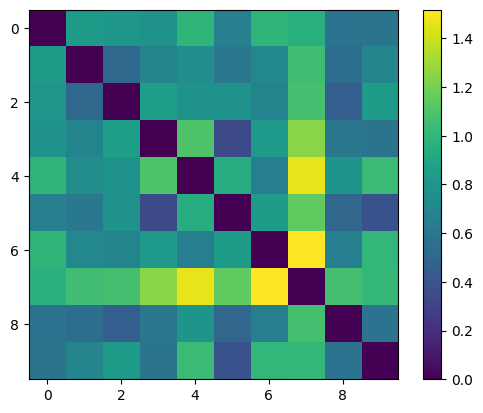

In [22]:
im = plt.imshow(distance_full[0:10,0:10])
plt.colorbar(im)

In [23]:
# Test for PSD
def test_kernel_psd(distance_matrix, kernel_func):
    """Test if kernel matrix is positive semi-definite"""
    import numpy as np
    
    # Compute full kernel matrix
    n = distance_matrix.shape[0]
    K = kernel_func(np.arange(n).reshape(-1, 1), 
                    np.arange(n).reshape(-1, 1), 
                    hps=[1.0, 1.0])  # Test hyperparameters
    
    # Check eigenvalues
    eigenvalues = np.linalg.eigvalsh(K)
    min_eigenvalue = np.min(eigenvalues)
    
    print(f"Minimum eigenvalue: {min_eigenvalue}")
    
    if min_eigenvalue < -1e-10:  # Negative beyond numerical error
        print("❌ NOT positive semi-definite!")
        return False
    elif min_eigenvalue < 0:
        print("⚠️  Slightly negative (numerical error)")
        return True
    else:
        print("✅ Positive semi-definite")
        return True

# Test each distance
for dist_name in ['sliced_Wass', 'Wass2D', 'FGW', 'JS']:
    print(f"\n{dist_name}:")
    distance_full = np.load(f'digits_distance_{dist_name}.npy')
    test_kernel_psd(distance_full, my_kernel)
    


sliced_Wass:
Minimum eigenvalue: 0.010727348438667642
✅ Positive semi-definite

Wass2D:
Minimum eigenvalue: -0.6689532504048883
❌ NOT positive semi-definite!

FGW:
Minimum eigenvalue: -6.123464421570806
❌ NOT positive semi-definite!

JS:
Minimum eigenvalue: -1.6797181144569493
❌ NOT positive semi-definite!


In [24]:
# Step 2 (Fixed): Define the basic GP components

from gpcam import kernels

def my_kernel(x1, x2, hps):
    """
    x1, x2: arrays of indices (either train_idx or test_idx)
    """
    # x1 and x2 ARE the indices - just extract them
    x1_idx = x1.astype(int).flatten()
    x2_idx = x2.astype(int).flatten()
    
    # Get distances from full precomputed matrix
    my_distance = distance_full[np.ix_(x1_idx, x2_idx)]
    
    # Apply Matern kernel
    k = hps[0] * kernels.matern_kernel_diff1(my_distance, hps[1])
    
    return k

def my_noise(x, hps):
    s = np.ones(len(x)) * 1e-6
    return np.diag(s)

def my_mean(x, hps):
    m = np.ones(len(x)) * 0 # hps[2]
    return m

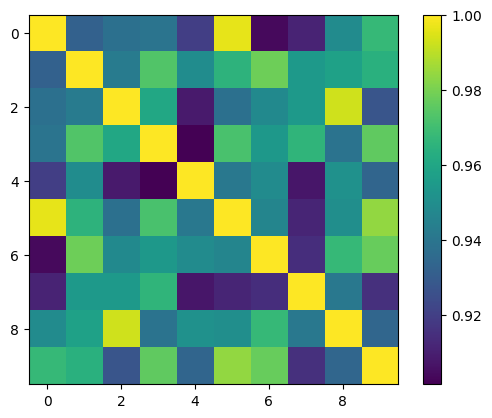

In [25]:
hps = np.array([1,1,1])
im = plt.imshow(my_kernel(X_train,X_train,hps)[0:10,0:10])
plt.colorbar(im)

(array([1.86500e+03, 1.80600e+03, 6.84600e+03, 1.31280e+04, 1.88140e+04,
        2.36280e+04, 2.80980e+04, 3.39480e+04, 4.08400e+04, 5.13180e+04,
        6.53520e+04, 8.31620e+04, 1.02478e+05, 1.23770e+05, 1.46200e+05,
        1.63916e+05, 1.81156e+05, 1.91466e+05, 1.99136e+05, 2.02038e+05,
        1.98504e+05, 1.90220e+05, 1.79544e+05, 1.62926e+05, 1.49370e+05,
        1.30838e+05, 1.14366e+05, 9.60240e+04, 7.97420e+04, 6.37220e+04,
        4.99600e+04, 3.90360e+04, 2.91400e+04, 2.09220e+04, 1.50040e+04,
        1.02740e+04, 7.26000e+03, 4.79200e+03, 3.05000e+03, 2.13000e+03,
        1.25200e+03, 8.66000e+02, 5.74000e+02, 3.26000e+02, 1.64000e+02,
        1.14000e+02, 6.20000e+01, 3.40000e+01, 2.40000e+01, 4.00000e+00]),
 array([0.        , 0.0096155 , 0.01923101, 0.02884651, 0.03846201,
        0.04807751, 0.05769302, 0.06730852, 0.07692402, 0.08653953,
        0.09615503, 0.10577053, 0.11538603, 0.12500154, 0.13461704,
        0.14423254, 0.15384805, 0.16346355, 0.17307905, 0.182694

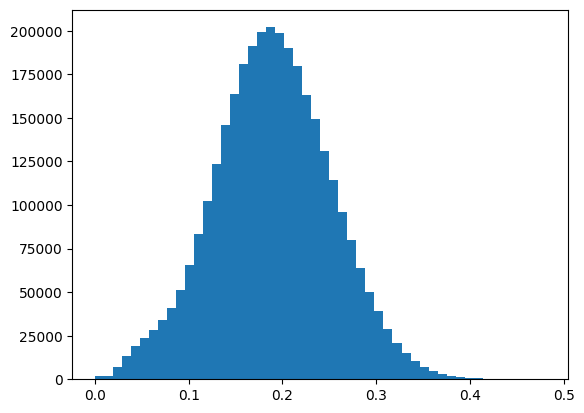

In [26]:
plt.hist(distance_full.flatten(), bins=50)

# Running One GP model training

In [27]:
# Step 4: Configure hyperparameters and initialize GPOptimizer

# Define hyperparameter bounds
bounds = np.empty((2, 2))
bounds[0] = np.array([1e-2, 1])     # sigma_f: signal variance      
bounds[1] = np.array([1e-3, 2])       # length_scale
#bounds[2] = np.array([0, 1])         #  mean

# Initial hyperparameters (middle of bounds)
init_hps = np.mean(bounds, axis=1)
print(f"\nInitial hyperparameters: {init_hps}")

my_gpo = GPOptimizer(X_train, y_train,
                     init_hyperparameters=init_hps,
                     kernel_function=my_kernel,
                     prior_mean_function=my_mean, 
                     noise_function=my_noise,
                        )

initial_log_likelihood = my_gpo.log_likelihood(init_hps)
print(f"Initial log likelihood: {initial_log_likelihood:.6f}")


# Step 5: Train the GP model
my_gpo.train(hyperparameter_bounds=bounds, init_hyperparameters=init_hps, method='global') #, max_iter=10000)

# Get optimized hyperparameters
final_hps = my_gpo.get_hyperparameters()
final_ll = my_gpo.log_likelihood(final_hps)
print(f"Final hyperparameters:   {final_hps}")
print(f"Final log likelihood:    {final_ll:.2f}")



Initial hyperparameters: [0.505  1.0005]


LinAlgError: 6-th leading minor of the array is not positive definite

RMSE: 4.91982432034553e-06


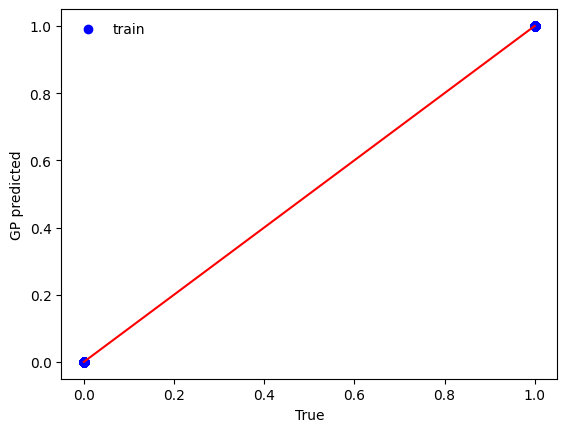

In [62]:
f_train = my_gpo.posterior_mean(X_train)["m(x)"]

my_line = np.linspace(np.min(y_train),np.max(y_train),10)

print('RMSE:', my_gpo.rmse(X_train,y_train)) # *100/np.mean(y_train),'%')

plt.scatter(y_train,f_train,color="blue",label = 'train')
plt.plot(my_line,my_line,c="red")
plt.xlabel("True")
plt.ylabel("GP predicted")
plt.legend(frameon = False)
plt.show()

RMSE: 0.1608761343430654


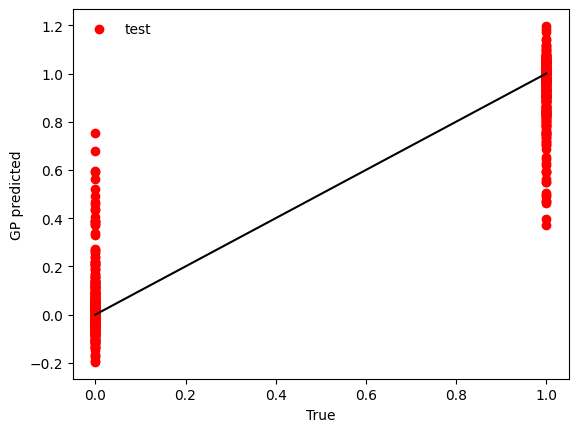

In [63]:
f = my_gpo.posterior_mean(X_test)["m(x)"]
posterior_var = my_gpo.posterior_covariance(X_test, variance_only=True, add_noise=False) # it does not matter if we added noise because it is 1e-6
var = posterior_var["v(x)"].flatten()

print('RMSE:', my_gpo.rmse(X_test,y_test)) # *100/np.mean(y_test),'%')

my_line = np.linspace(np.min(y_test),np.max(y_train),10)

plt.scatter(y_test,f,color="red",label = 'test')
#plt.scatter(y_train,f_train,color="blue",label = 'train')
plt.plot(my_line,my_line,c="black")
plt.xlabel("True")
plt.ylabel("GP predicted")
plt.legend(frameon = False)
plt.show()

In [64]:
from sklearn.metrics import brier_score_loss
from scipy.stats import norm

def probit(mu, sigma2):
    """
    Probit link function - converts GP mean and variance to probabilities
    Better than sigmoid because it accounts for uncertainty!
    """
    adjusted_mu = mu / np.sqrt(1 + sigma2)
    return norm.cdf(adjusted_mu)

# Convert GP predictions to probabilities using probit
y_pred_proba = probit(f, var)

#######################
# Evaluate (y_test is already binary!)
brier_score = brier_score_loss(y_test, y_pred_proba)  # ✅ y_test is already 0/1
y_pred_class = (y_pred_proba > 0.5).astype(int)
accuracy = np.mean(y_pred_class == y_test)  # ✅ y_test is already 0/1

print(f"Brier Score: {brier_score:.4f}")
print(f"Accuracy: {accuracy:.4f}")


Brier Score: 0.1549
Accuracy: 0.7000


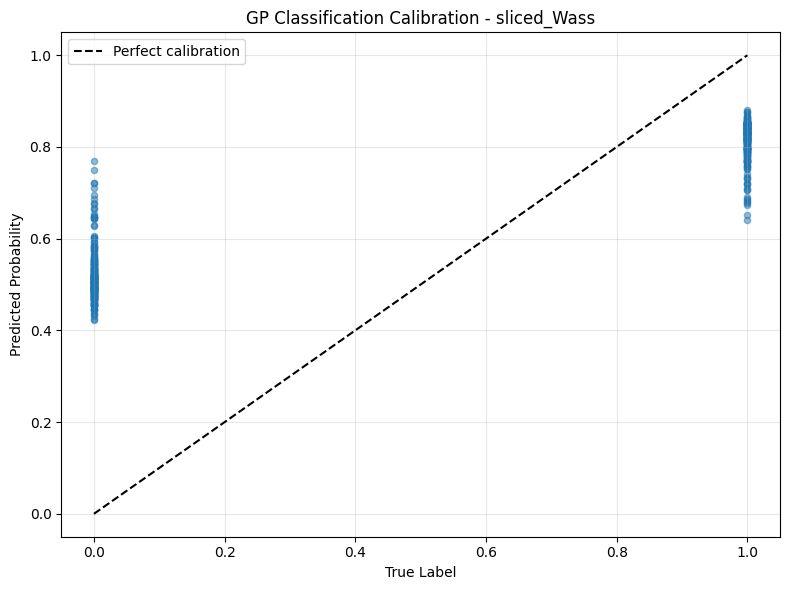

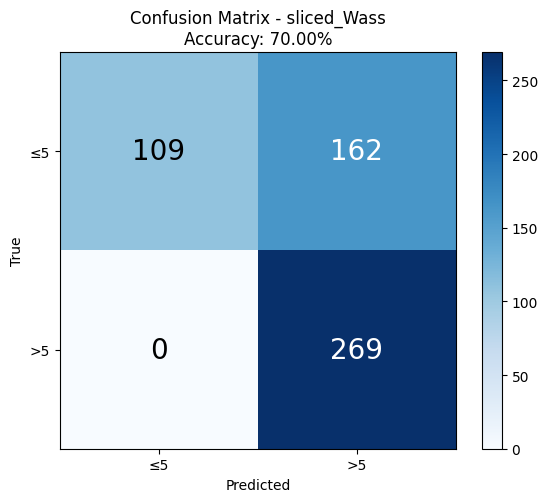

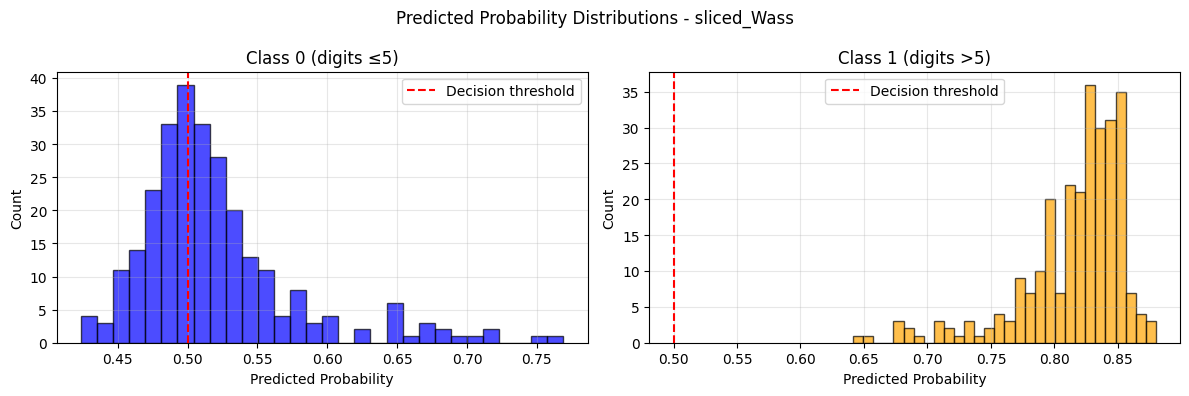

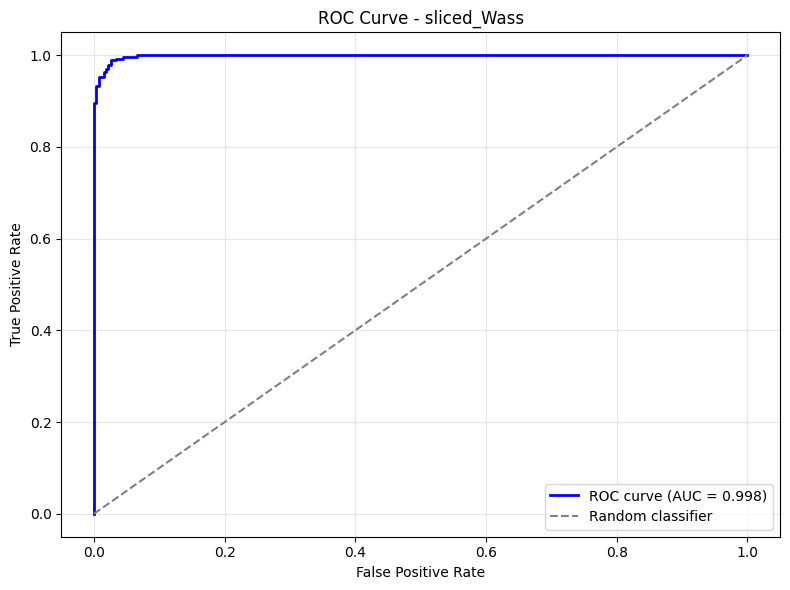

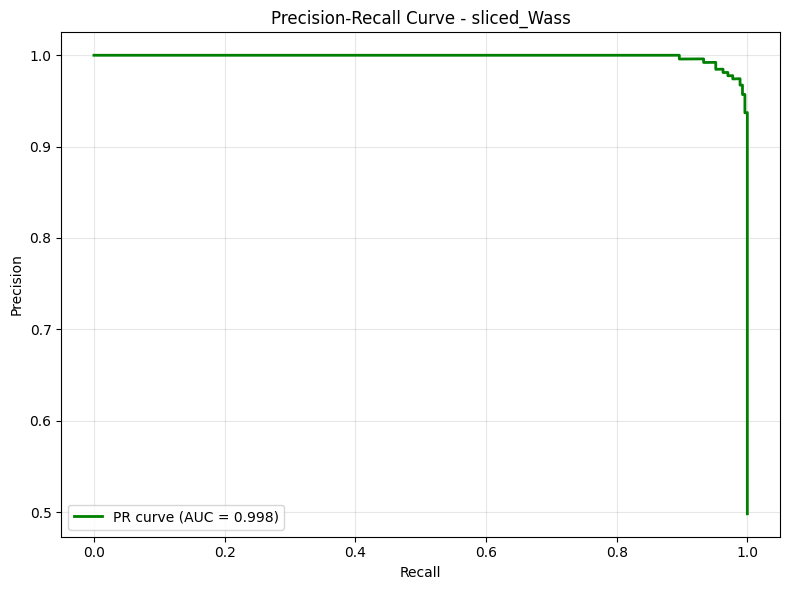

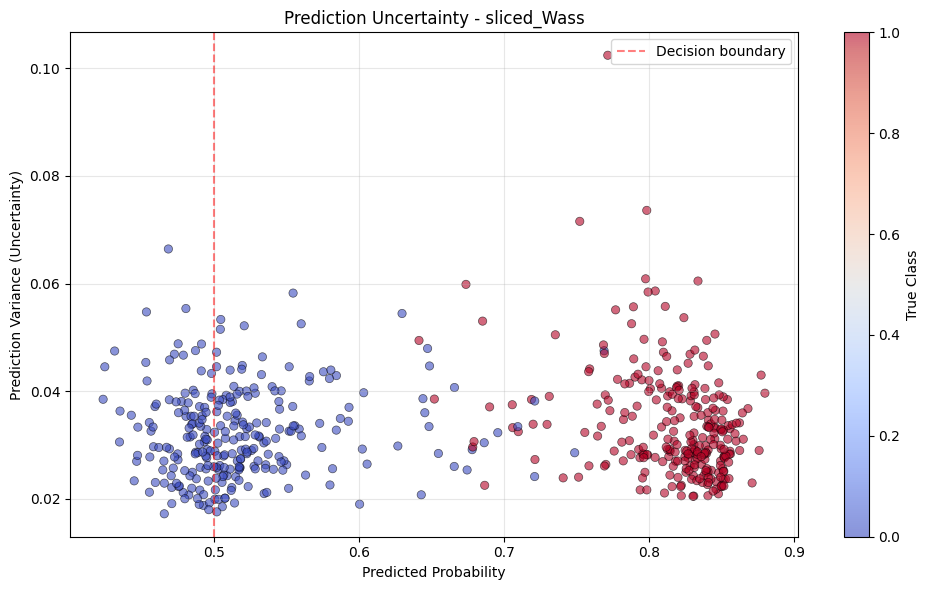

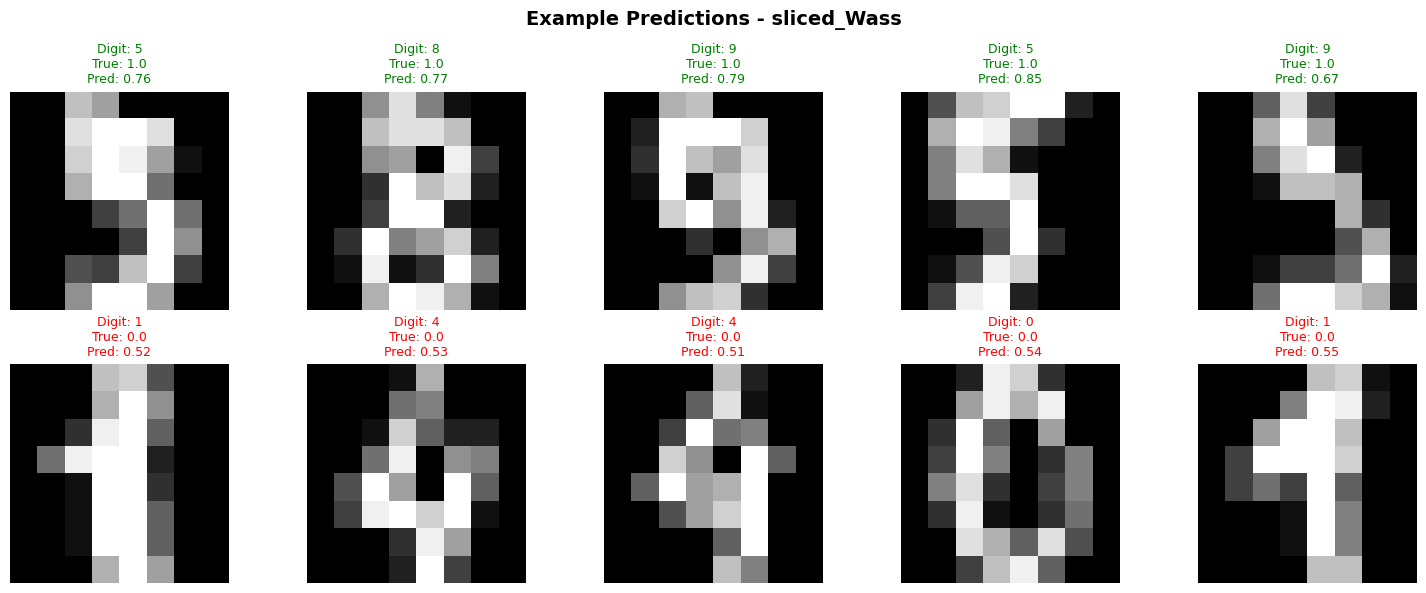


SUMMARY STATISTICS
Distance Metric: sliced_Wass
Accuracy: 0.7000
Brier Score: 0.1549
ROC AUC: 0.9984
PR AUC: 0.9984

Predicted probabilities range: [0.424, 0.880]
Mean uncertainty (variance): 0.0330
Correct predictions: 378/540
Incorrect predictions: 162/540


In [65]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve
import numpy as np

# ===== 1. CALIBRATION PLOT =====
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_proba, alpha=0.5, s=20)
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
plt.xlabel('True Label')
plt.ylabel('Predicted Probability')
plt.title(f'GP Classification Calibration - {DISTANCE_METRIC}')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ===== 2. CONFUSION MATRIX =====
cm = confusion_matrix(y_test, y_pred_class)
plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap='Blues', interpolation='nearest')
plt.colorbar()

# Add text annotations
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center', 
                fontsize=20, color='white' if cm[i, j] > cm.max()/2 else 'black')

plt.xticks([0, 1], ['≤5', '>5'])
plt.yticks([0, 1], ['≤5', '>5'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix - {DISTANCE_METRIC}\nAccuracy: {accuracy:.2%}')
plt.tight_layout()
plt.show()

# ===== 3. PROBABILITY DISTRIBUTIONS BY CLASS =====
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class 0 (digits ≤5)
axes[0].hist(y_pred_proba[y_test == 0], bins=30, alpha=0.7, color='blue', edgecolor='black')
axes[0].axvline(0.5, color='red', linestyle='--', label='Decision threshold')
axes[0].set_xlabel('Predicted Probability')
axes[0].set_ylabel('Count')
axes[0].set_title('Class 0 (digits ≤5)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Class 1 (digits >5)
axes[1].hist(y_pred_proba[y_test == 1], bins=30, alpha=0.7, color='orange', edgecolor='black')
axes[1].axvline(0.5, color='red', linestyle='--', label='Decision threshold')
axes[1].set_xlabel('Predicted Probability')
axes[1].set_ylabel('Count')
axes[1].set_title('Class 1 (digits >5)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Predicted Probability Distributions - {DISTANCE_METRIC}')
plt.tight_layout()
plt.show()

# ===== 4. ROC CURVE =====
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve - {DISTANCE_METRIC}')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ===== 5. PRECISION-RECALL CURVE =====
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
pr_auc = auc(recall, precision)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='green', lw=2, label=f'PR curve (AUC = {pr_auc:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve - {DISTANCE_METRIC}')
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ===== 6. UNCERTAINTY VISUALIZATION =====
plt.figure(figsize=(10, 6))
scatter = plt.scatter(y_pred_proba, var, c=y_test, cmap='coolwarm', 
                     alpha=0.6, edgecolors='black', linewidth=0.5)
plt.colorbar(scatter, label='True Class')
plt.xlabel('Predicted Probability')
plt.ylabel('Prediction Variance (Uncertainty)')
plt.title(f'Prediction Uncertainty - {DISTANCE_METRIC}')
plt.axvline(0.5, color='red', linestyle='--', alpha=0.5, label='Decision boundary')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ===== 7. SHOW EXAMPLE PREDICTIONS WITH ACTUAL IMAGES =====
# Get some correct and incorrect predictions
correct_idx = np.where(y_pred_class == y_test)[0]
incorrect_idx = np.where(y_pred_class != y_test)[0]

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

# Show 5 correct predictions
for i, idx in enumerate(correct_idx[:5]):
    test_sample_idx = test_idx[idx]
    img = digits.images[test_sample_idx]
    true_digit = numerical_values[test_sample_idx]
    
    axes[0, i].imshow(img, cmap='gray')
    axes[0, i].set_title(f'Digit: {true_digit}\nTrue: {y_test[idx]}\n'
                         f'Pred: {y_pred_proba[idx]:.2f}', 
                         fontsize=9, color='green')
    axes[0, i].axis('off')

# Show 5 incorrect predictions
for i, idx in enumerate(incorrect_idx[:5] if len(incorrect_idx) >= 5 else incorrect_idx):
    test_sample_idx = test_idx[idx]
    img = digits.images[test_sample_idx]
    true_digit = numerical_values[test_sample_idx]
    
    axes[1, i].imshow(img, cmap='gray')
    axes[1, i].set_title(f'Digit: {true_digit}\nTrue: {y_test[idx]}\n'
                         f'Pred: {y_pred_proba[idx]:.2f}', 
                         fontsize=9, color='red')
    axes[1, i].axis('off')

# Hide empty subplots if not enough incorrect predictions
if len(incorrect_idx) < 5:
    for i in range(len(incorrect_idx), 5):
        axes[1, i].axis('off')

axes[0, 0].set_ylabel('CORRECT', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('INCORRECT', fontsize=12, fontweight='bold')

plt.suptitle(f'Example Predictions - {DISTANCE_METRIC}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ===== 8. SUMMARY STATISTICS =====
print("\n" + "="*70)
print("SUMMARY STATISTICS")
print("="*70)
print(f"Distance Metric: {DISTANCE_METRIC}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Brier Score: {brier_score:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print(f"PR AUC: {pr_auc:.4f}")
print(f"\nPredicted probabilities range: [{y_pred_proba.min():.3f}, {y_pred_proba.max():.3f}]")
print(f"Mean uncertainty (variance): {var.mean():.4f}")
print(f"Correct predictions: {np.sum(y_pred_class == y_test)}/{len(y_test)}")
print(f"Incorrect predictions: {np.sum(y_pred_class != y_test)}/{len(y_test)}")

In [ ]:
# Results Summary:

# Distance Metric: sliced_Wass
# Accuracy: 0.7000
# Brier Score: 0.1549
# ROC AUC: 0.9984
# PR AUC: 0.9984

# Predicted probabilities range: [0.424, 0.880]
# Mean uncertainty (variance): 0.0330
# Correct predictions: 378/540
# Incorrect predictions: 162/540

# Other distances are not resulting in PSD kernel matrix
